**ML COURSE 2025-2026**
# Esame - 1° Appello - 15/06/2026

**ISTRUZIONI**
- Completa **tutte le sezioni** dove trovi scritto <span style="color:red"><strong>TODO</strong></span> e <span style="color:red"><strong>Risposta</strong></span>

  
  - In alcuni casi, <span style="color:red"><strong>Risposta</strong></span> sarà all'interno di una **cella di testo**: in quel caso, dovrai rispondere **a parole** alla domanda posta.  
  
  - In altri casi, sarà all'interno di una **cella di codice**: in quel caso, dovrai completare la cella **implementando quanto richiesto**.



- **Aggiungi commenti al codice** per spiegare chiaramente cosa stai facendo. Questo passaggio è molto importante: in alcuni casi è **più importante del codice stesso**.

- Assicurati che, cliccando su **"Restart and Run All"**, il codice funzioni **senza errori**, per quanto possibile.

- **Motiva le scelte più critiche**.



**Quando hai finito**:

1. Scarica il notebook.  
2. Caricalo su **Moodle Esami**.



 *(In seguito troverai uno screenshot che mostra come scaricare il notebook da Jupyter.)*

![Screenshot: come scaricare il notebook da Jupyter](istruzioniDownload.png)


In [1]:
# AGGIUNGI I TUOI DATI
n_matricola = 000000
nome = "..."
cognome = "..."

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from exam_utils import random_train_test_split

## 1. Preprocessing e Data Analysis
Il seguente dataset è una versione ridotta di Ames Housing, un dataset che raccoglie caratteristiche di case in Ames, Iowa, USA.
Presenta le seguenti variabili:  

| Nome Feature          | Descrizione |
| ------------------    | --------------------------------------------------------------------------------- |
| `SalePrice`           | **Variabile target**: Prezzo di vendita della casa |
| `OverallQuality`      | Qualità generale del materiale e delle finiture |
| `GrLivArea`           | Area abitabile fuori terra ($\mathrm{feet}^2$) |
| `TotalBsmtSF`         | Area totale semi/interrata ($\mathrm{feet}^2$) |
| `2ndFlrSF`            | Area totale secondo piano ($\mathrm{feet}^2$) |
| `GarageCars`          | Area garage in termini di numero auto | 
| `LotArea`             | Area lotto ($\mathrm{feet}^2$) | 
| `GarageArea`          | Area garage ($\mathrm{feet}^2$) | 
| `YearBuilt`           | Anno di costruzione | 
| `Fence`               | Qualità della recinzione |
| `PoolArea`            | Area piscina ($\mathrm{feet}^2$)|
| `Foundation`          | Tipo di fondamenta | 
| `LandContour`         | Conformazione piangeggiante del terreno | 
| `Neighborhood`        | Quartiere in cui è locata la zona |
| `Heating`             | Tipo di riscaldamento | 
| `RoofStyle`           | Tipo di tetto | 
| `PoolQC`              | Qualità della piscina|


In [3]:
data_df = pd.read_csv("AmesHousing_modified.csv")
data_df = data_df.sample(n=1100, random_state = n_matricola).reset_index(drop=True)

<span style="color:red"><strong>TODO 1</strong></span>

Esplora il dataset, **implementando** tecniche e visualizzazioni viste a lezione. Per ogni aspetto analizzato, **commenta** perché è utile per la costruzione di un modello di machine learning e quali possono essere le implicazioni. 

In [4]:
# Risposta 1: 
...

Ellipsis

In [5]:
# SOLUZIONE

# 1. Descrizione generale: ci aiuta a identificare variabili numeriche e categoriche, 
# valori mancanti, outliers e informazioni generali sulla distribuzione dei dati. 
data_summary = data_df.describe(include="all").transpose()
display(data_summary)
display(data_df.info())

feature_names = data_df.columns.tolist()
categorical_features = ["Fence", "Foundation", "LandContour", "Neighborhood", "Heating", "RoofStyle"]
numerical_features = [col for col in feature_names if col not in categorical_features and col != "SalePrice"]

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SalePrice,1100.0,NaN,NaN,NaN,183199.260909,82116.481093,34900.0,130000.0,164845.0,215000.0,755000.0
OverallQual,1098.0,NaN,NaN,NaN,6.144809,1.411625,1.0,5.0,6.0,7.0,10.0
GrLivArea,1100.0,NaN,NaN,NaN,1533.308182,540.231697,334.0,1151.5,1470.0,1792.0,5642.0
TotalBsmtSF,1098.0,NaN,NaN,NaN,1064.193078,452.849478,0.0,789.75,1002.0,1310.75,6110.0
2ndFlrSF,1095.0,NaN,NaN,NaN,356.389954,444.33621,0.0,0.0,0.0,736.0,2065.0
GarageCars,1098.0,NaN,NaN,NaN,1.783242,0.768815,0.0,1.0,2.0,2.0,4.0
LotArea,1098.0,NaN,NaN,NaN,10586.274135,10156.574377,1477.0,7536.25,9501.5,11644.5,215245.0
GarageArea,1099.0,NaN,NaN,NaN,477.195632,219.130848,0.0,336.0,480.0,577.0,1418.0
YearBuilt,1098.0,NaN,NaN,NaN,1971.106557,30.921351,1872.0,1952.25,1973.0,2001.0,2010.0
Fence,1099,5,NO-FENCE,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1100 non-null   int64  
 1   OverallQual   1098 non-null   float64
 2   GrLivArea     1100 non-null   int64  
 3   TotalBsmtSF   1098 non-null   float64
 4   2ndFlrSF      1095 non-null   float64
 5   GarageCars    1098 non-null   float64
 6   LotArea       1098 non-null   float64
 7   GarageArea    1099 non-null   float64
 8   YearBuilt     1098 non-null   float64
 9   Fence         1099 non-null   str    
 10  PoolArea      1097 non-null   float64
 11  Foundation    1098 non-null   str    
 12  LandContour   1100 non-null   str    
 13  Neighborhood  1099 non-null   str    
 14  Heating       1097 non-null   str    
 15  RoofStyle     1098 non-null   str    
 16  PoolQC        1099 non-null   float64
dtypes: float64(9), int64(2), str(6)
memory usage: 146.2 KB


None

In [6]:
# 2. Valori mancanti: identificazione e gestione. 
missing_values_count = data_df.isna().sum()
print("Conteggio valori mancanti per ogni colonna:")
print(missing_values_count)


# in questo caso, dato che non sono tanti, possiamo fare imputazione con la mediana/media (numeriche)
# e con la moda (categoriche)
for col in numerical_features:
    median_value = data_df[col].median()
    data_df[col] = data_df[col].fillna(median_value)
for col in categorical_features:
    mode_value = data_df[col].mode()[0]
    data_df[col] = data_df[col].fillna(mode_value)

# count nan per assicurarsi che non ce ne siano più
nan_counts = data_df.isna().sum()
print("Conteggio valori mancanti dopo l'imputazione:")
print(nan_counts)

Conteggio valori mancanti per ogni colonna:
SalePrice       0
OverallQual     2
GrLivArea       0
TotalBsmtSF     2
2ndFlrSF        5
GarageCars      2
LotArea         2
GarageArea      1
YearBuilt       2
Fence           1
PoolArea        3
Foundation      2
LandContour     0
Neighborhood    1
Heating         3
RoofStyle       2
PoolQC          1
dtype: int64
Conteggio valori mancanti dopo l'imputazione:
SalePrice       0
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
2ndFlrSF        0
GarageCars      0
LotArea         0
GarageArea      0
YearBuilt       0
Fence           0
PoolArea        0
Foundation      0
LandContour     0
Neighborhood    0
Heating         0
RoofStyle       0
PoolQC          0
dtype: int64


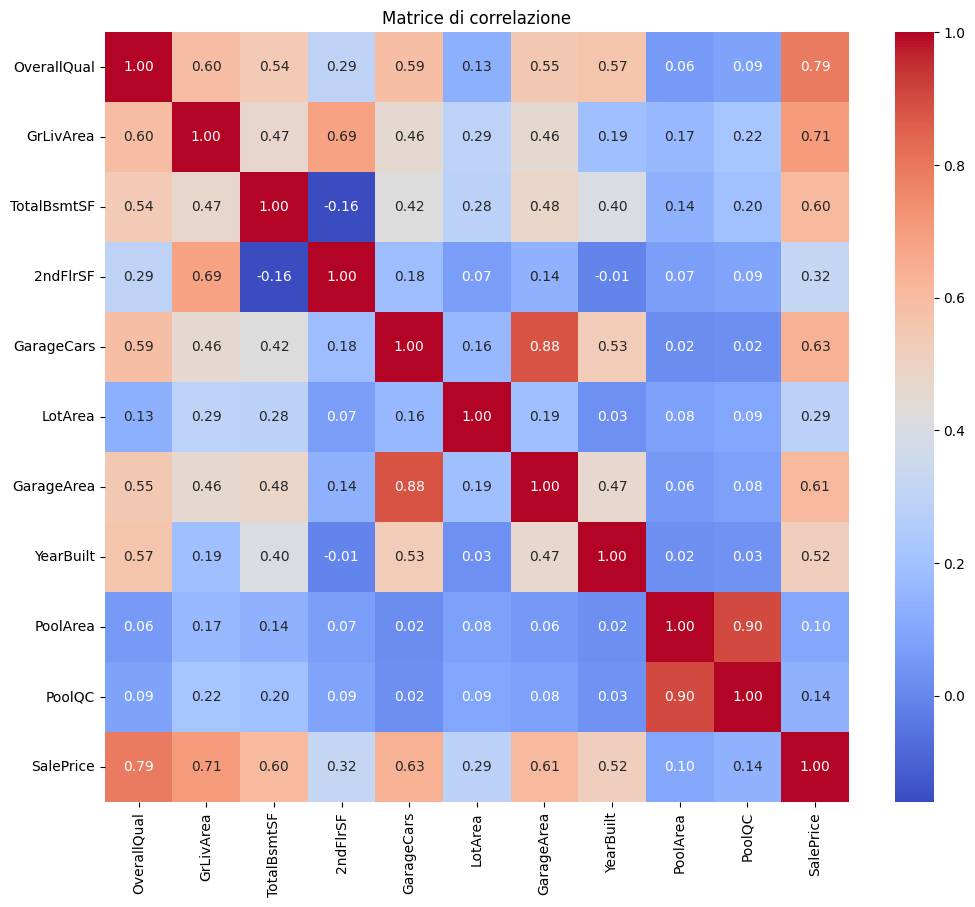

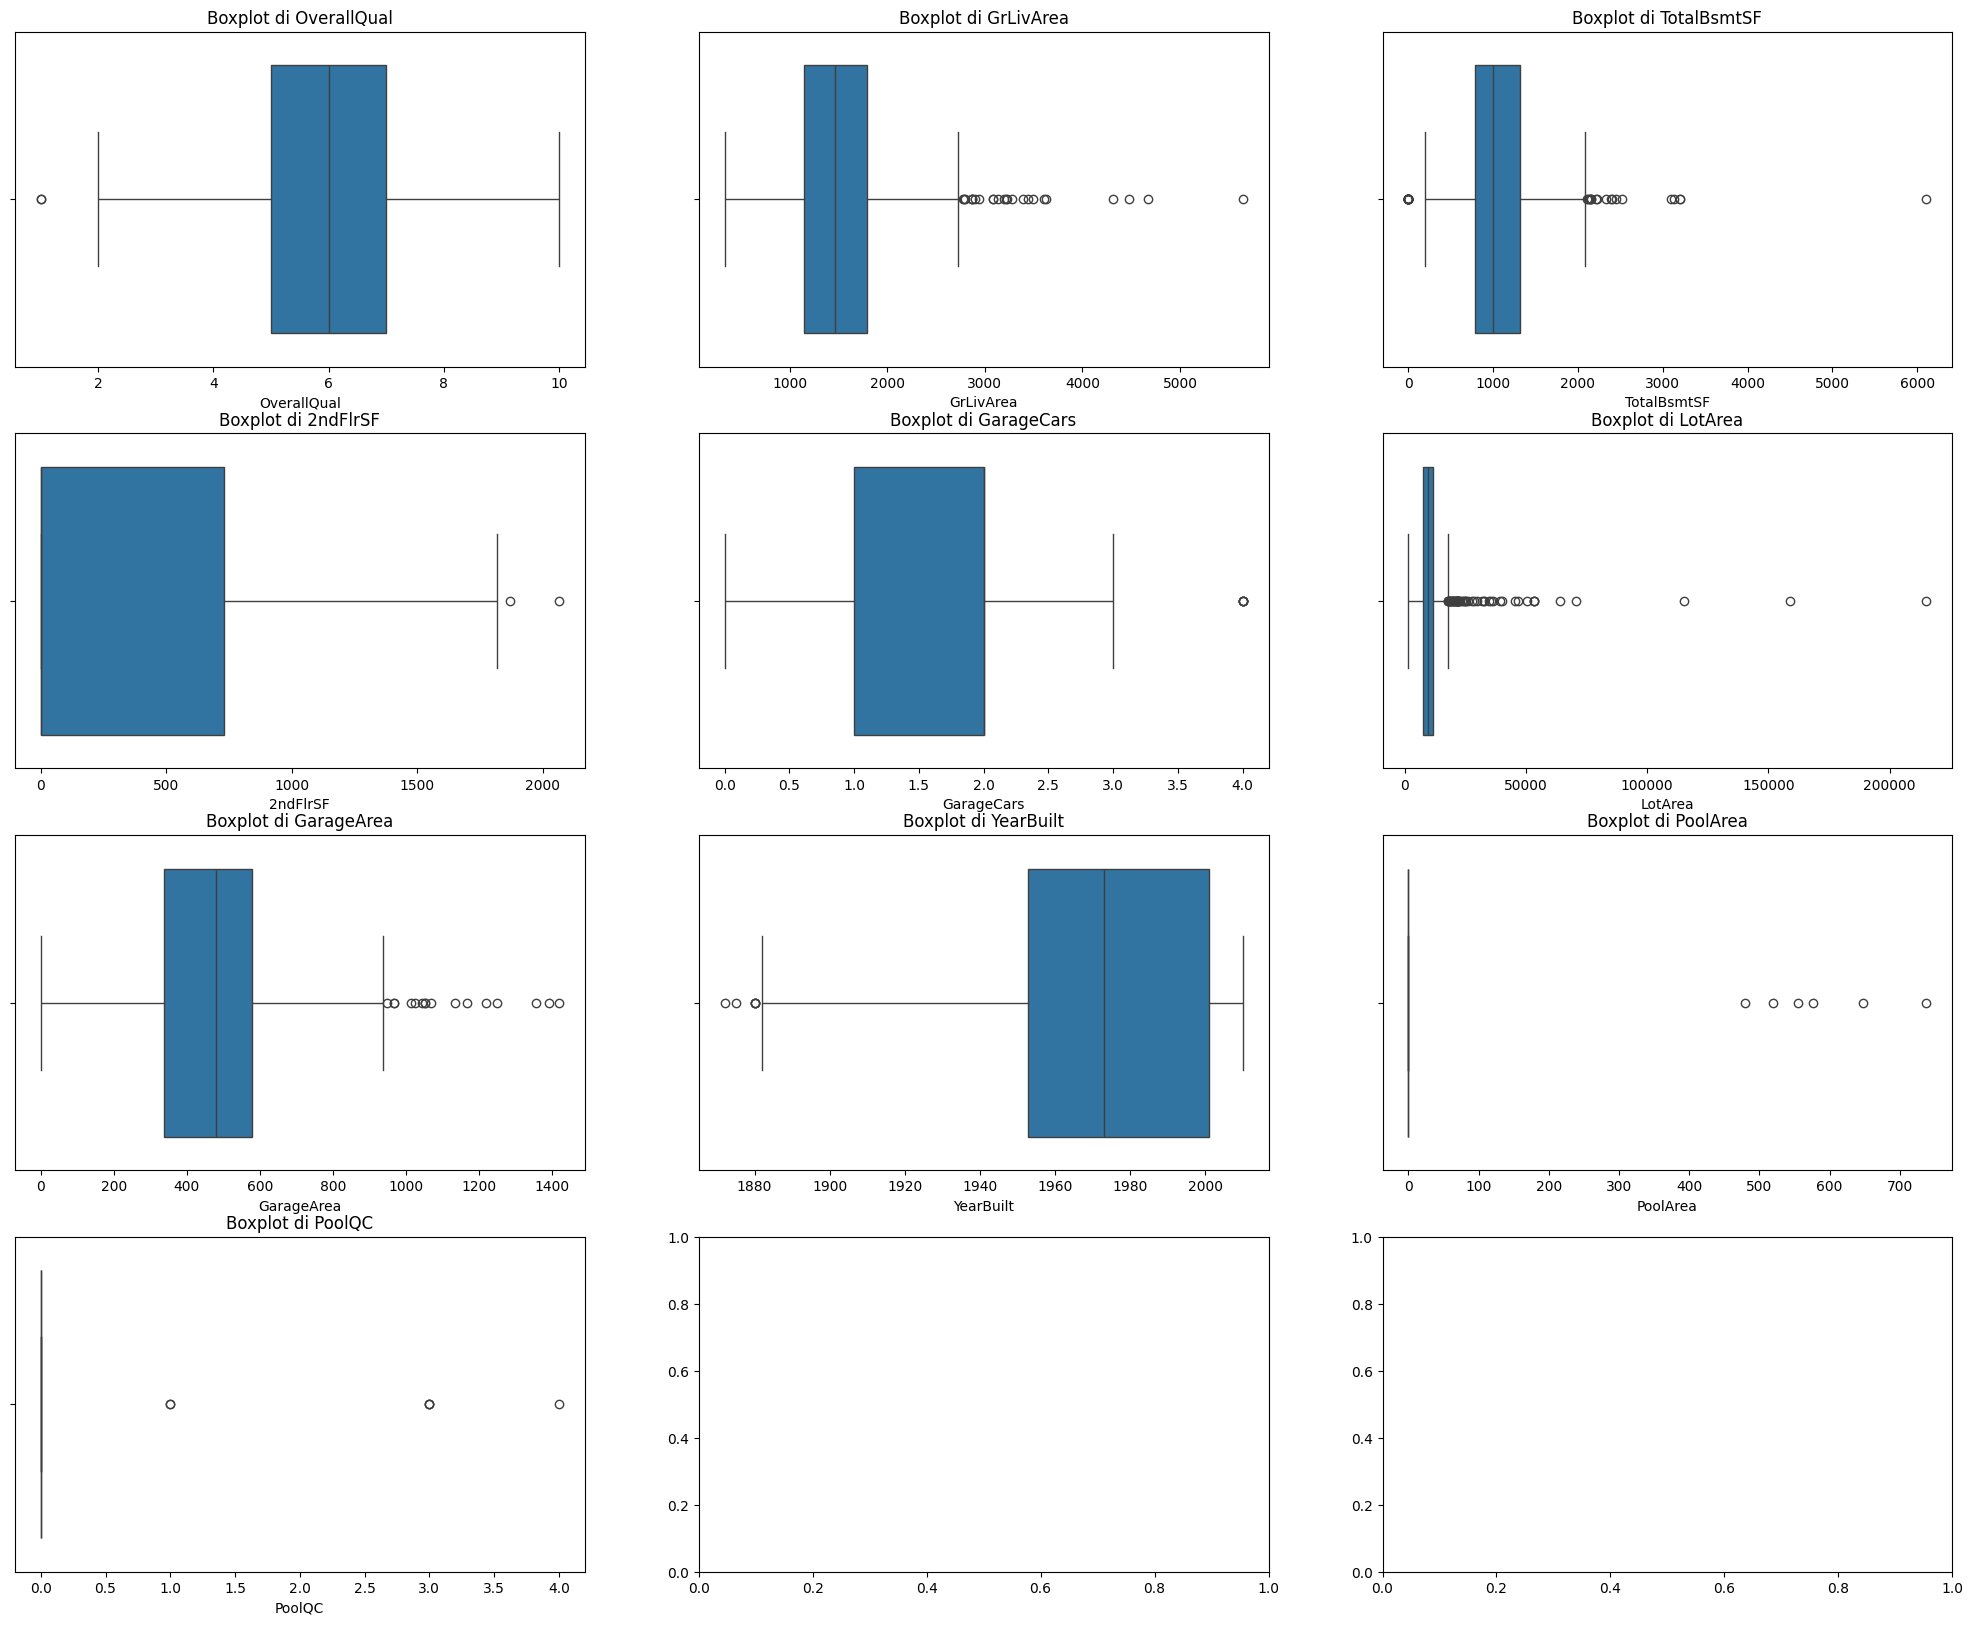

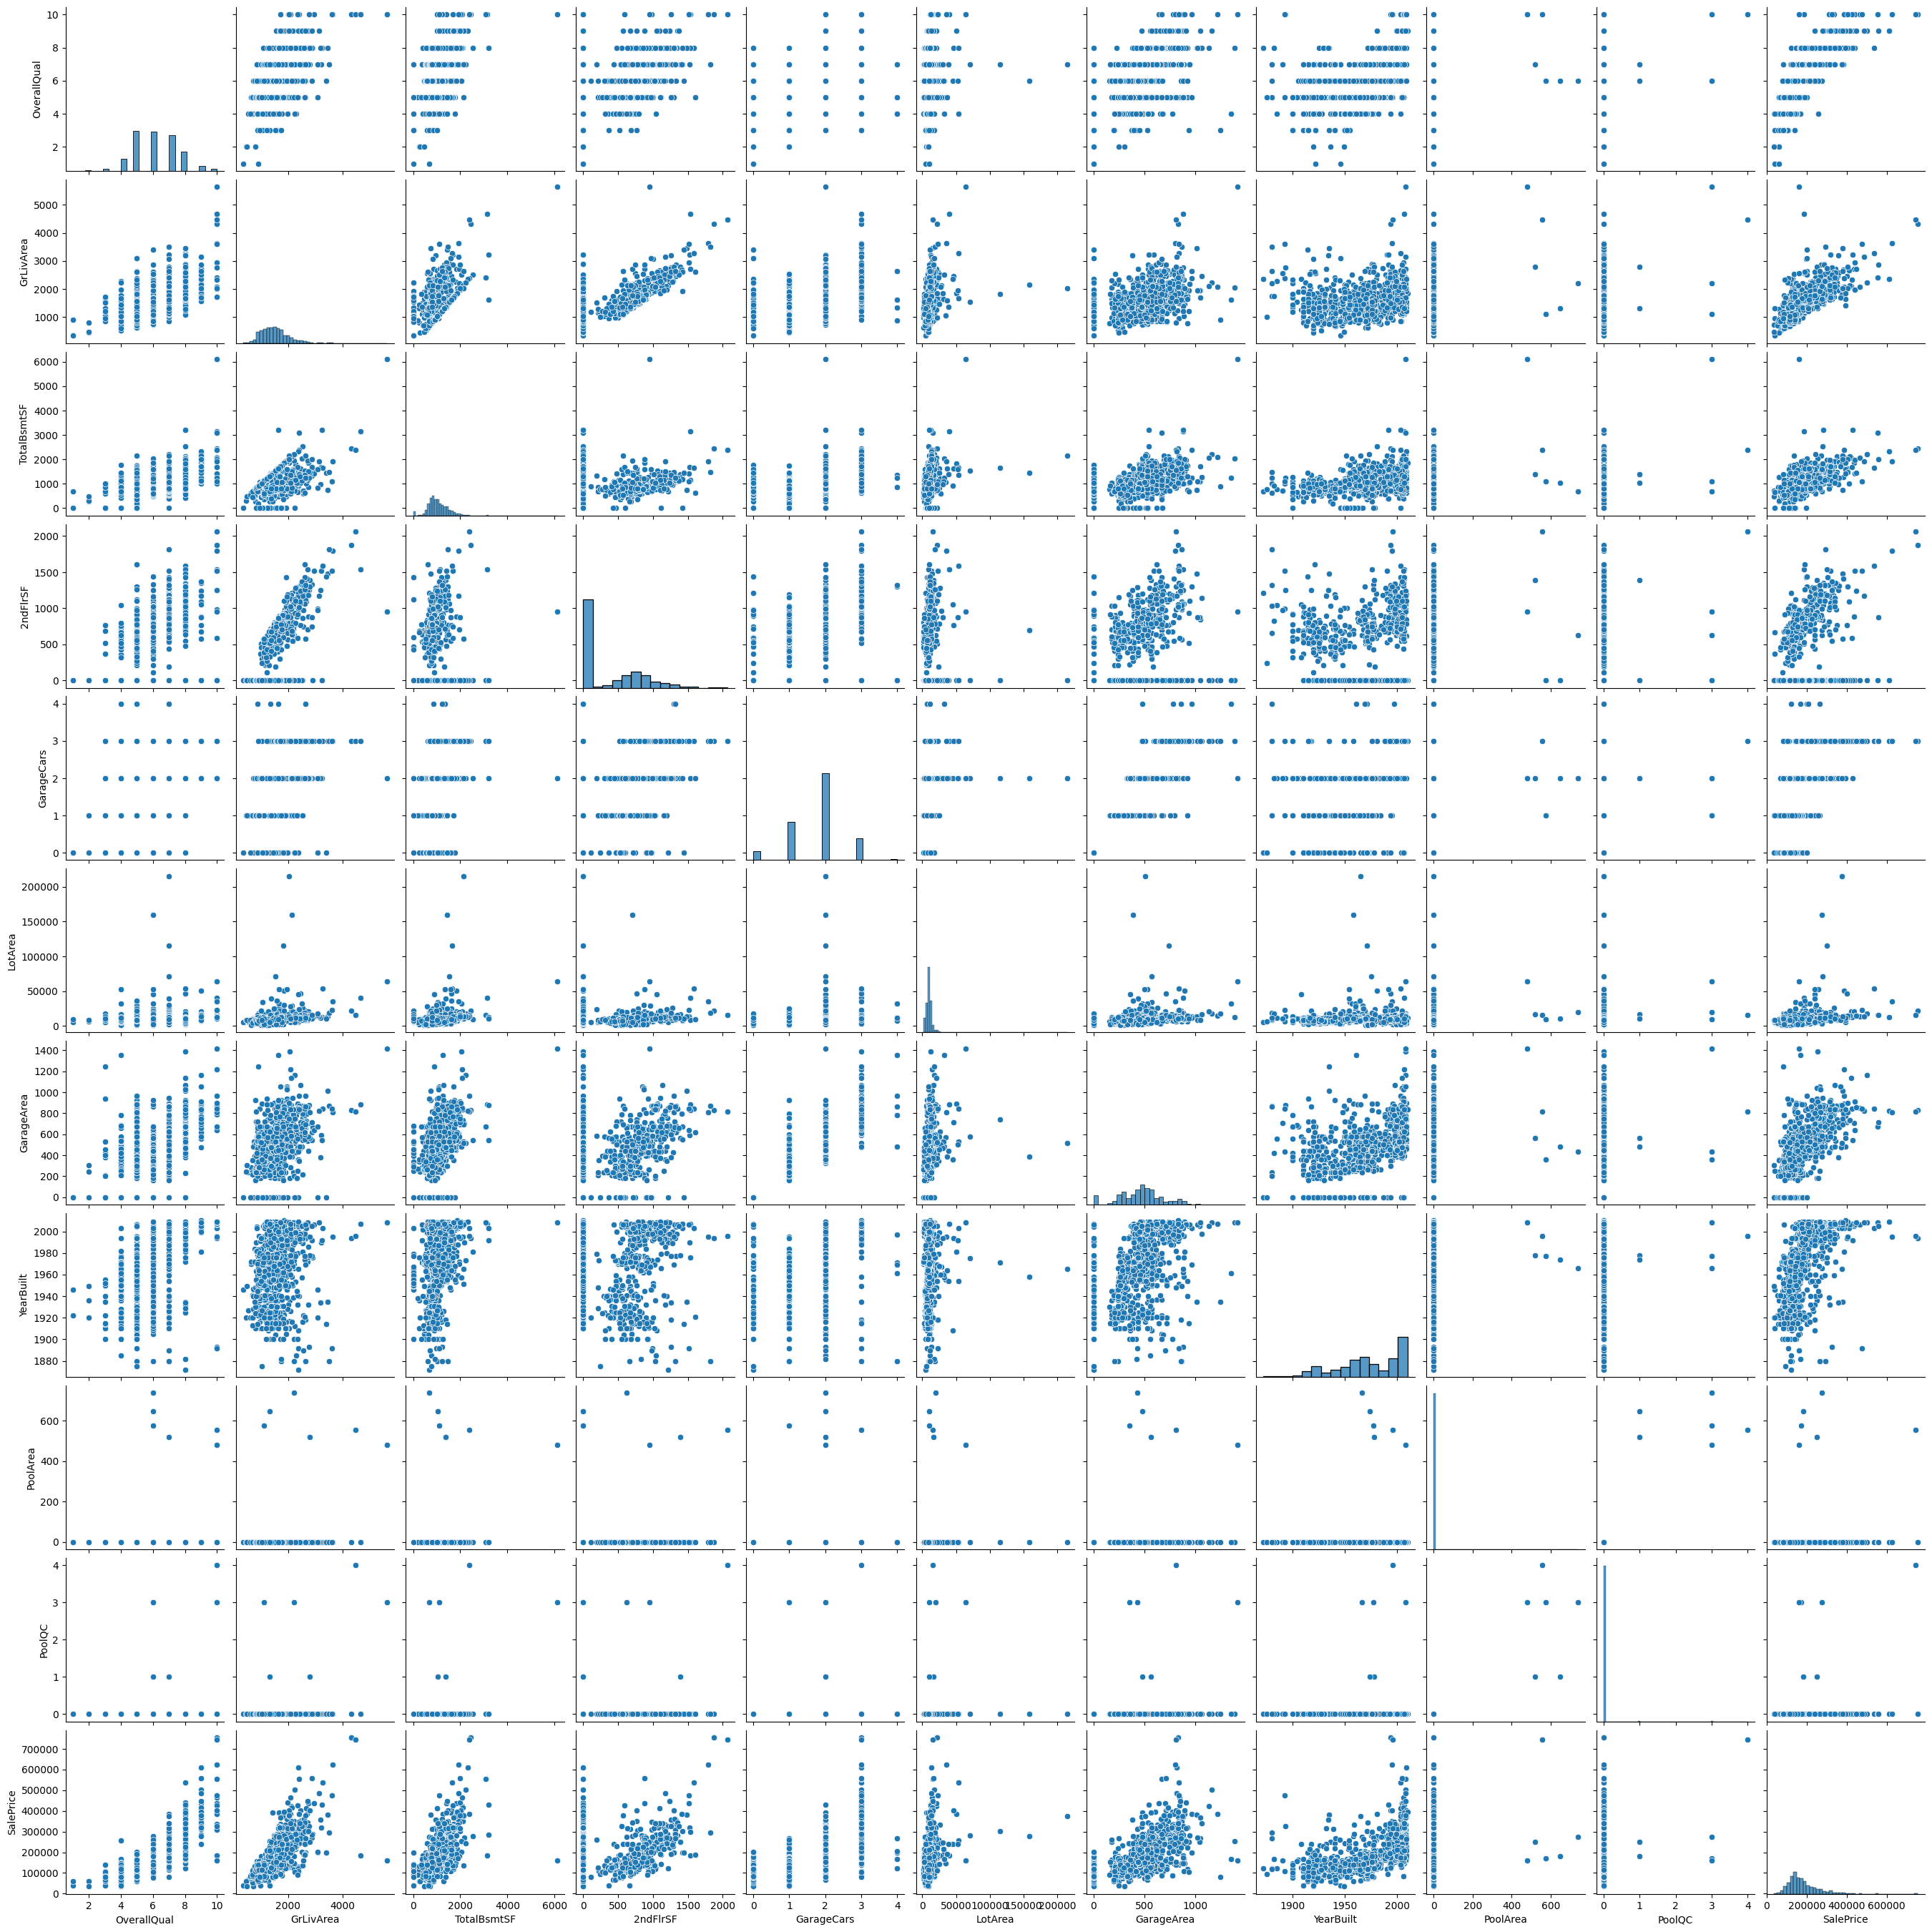

In [7]:
# 3. Analisi variabili numeriche
# 3.a correlazione tra variabili numeriche (con se stesse e target)
numerical_data = data_df[numerical_features + ["SalePrice"]]
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

# PoolQC e PoolArea hanno correlazione molto alta, così come GarageArea e GarageCars. 
# Possiamo quini pensare di rimuovere una delle due in ogni coppia. 
# Inoltre, PoolArea e PoolQC hanno correlazione molto bassa con SalePrice, quindi possiamo pensare
# di rimuoverle entrambe. 

# 3.b boxplot (per distribuzione e outliers (si può pensare anche di rimuovere outlier con IQR, ma dipende dal task)
plt.subplots(4, 3, figsize=(25, 20))
for i, col in enumerate(numerical_features[:11]):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=data_df[col])
    plt.title(f"Boxplot di {col}")

# 3.c pairplot (+ istogramma): per vedere relazioni lineari tra feature-feature e feature-target. 
sns.pairplot(numerical_data)
plt.show()
# per esempio si vede che SalePrice ha una chiara relazione lineare con OverallQual, GrLivArea, TotalBsmtSF. 
# Con altre variabili è più debole, o non c'è una relazione lineare evidente (e.s. PoolArea) 

Conteggio categorie per Fence:
Fence
NO-FENCE    892
MnPrv       115
GdPrv        47
GdWo         40
MnWw          6
Name: count, dtype: int64


Conteggio categorie per Foundation:
Foundation
PConc     489
CBlock    471
BrkTil    116
Slab       16
Stone       5
Wood        3
Name: count, dtype: int64


Conteggio categorie per LandContour:
LandContour
Lvl    979
Bnk     49
HLS     39
Low     33
Name: count, dtype: int64


Conteggio categorie per Neighborhood:
Neighborhood
NAmes      163
CollgCr    109
OldTown     91
Edwards     78
Somerst     68
NridgHt     62
NWAmes      58
Sawyer      53
Gilbert     52
BrkSide     44
SawyerW     43
Crawfor     42
NoRidge     35
Mitchel     35
Timber      29
IDOTRR      27
SWISU       23
ClearCr     22
StoneBr     17
Blmngtn     13
BrDale      13
MeadowV     12
Veenker      6
NPkVill      5
Name: count, dtype: int64


Conteggio categorie per Heating:
Heating
GasA    1077
GasW      13
Grav       5
Wall       3
OthW       2
Name: count, dtype: int64


Co

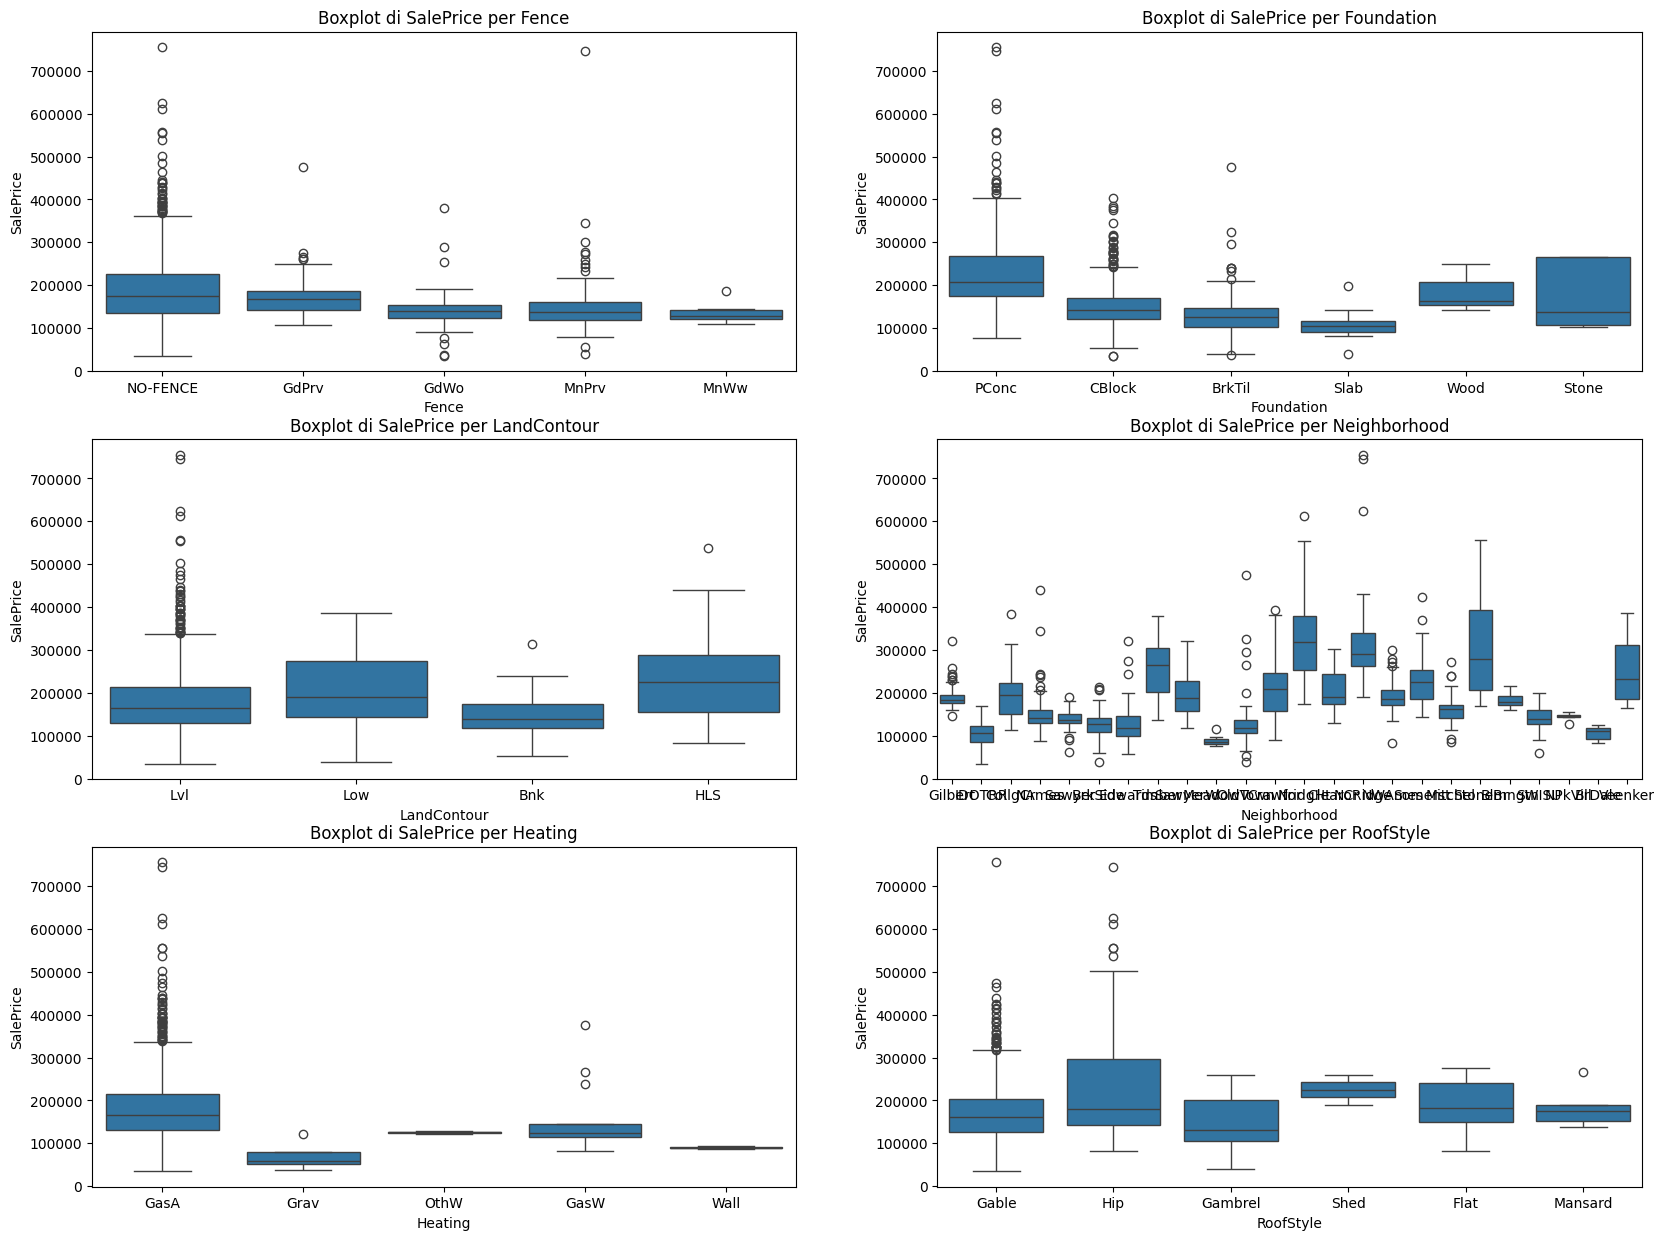

In [ ]:
# 4. Analisi variabili categoriche

# 4.a boxplot di target per ogni categoria: per vedere se ci sono differenze evidenti tra categorie.
plt.subplots(3, 2, figsize=(20, 15))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=data_df[col], y=data_df["SalePrice"])
    plt.title(f"Boxplot di SalePrice per {col}")

# possiamo vedere che, mentre 'Neighborhood' mostra differenze evidenti tra categorie, 'LandContour' (o 'Fence') no. Questo 
# ci può dare indicazioni su quali feature potrebbero essere più importanti per il task, ed eventualmente quali feature possiamo pensare di rimuovere. 

# 4.b conta quante variabili per categoria ci sono 
for col in categorical_features:
    print(f"Conteggio categorie per {col}:")
    print(data_df[col].value_counts())
    print("\n")

# possiamo vedere che ci sono degli sbilanciamenti, per esempio "NO-FENCE" è la categoria 
# più frequente per 'Fence', 'Gable' per 'RoofStyle', etc. 
# se queste feature sono importanti per il task, potrebbe essere necessario fare oversampling/undersampling o usare metriche adatte.




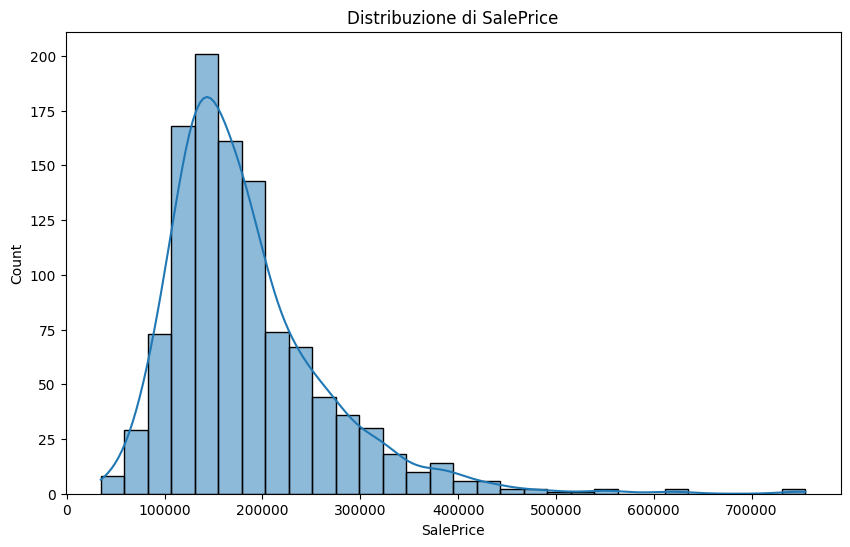

In [9]:
# 5. Analisi target
# possiamo plottare l'istogramma del target per vedere la distribuzione, e eventualmente fare trasformazioni (logaritmo, etc.) se è molto sbilanciato.
plt.figure(figsize=(10, 6))
sns.histplot(data_df["SalePrice"], bins=30, kde=True)
plt.title("Distribuzione di SalePrice")
plt.show()

# SalePrice presenta distribuzione asimmetrica a destra.

## 2. Modello di Machine Learning

A laboratorio abbiamo visto la Linear Regression con loss MSE (Ordinary Least Squares):

$$
\min_\beta L_{\mathrm{MSE}}
=
\min_\beta
\frac{1}{n}
\sum_{i=1}^{n}
\underbrace{\left(y_i - x_i^\top \beta\right)^2}_{\ell(y_i,\hat y_i)},
$$

(in forma vettoriale:$\min_\beta \frac{1}{n}\|y-\mathbf X\beta\|_2^2$). 

Oggi vogliamo sostituire la loss quadratica $\ell(y_i,\hat y_i)$ con una nuova loss "asimmetrica", che ha la forma

$$
\ell_\tau(y_i,\hat y_i)
=
\begin{cases}
\tau (y_i-\hat y_i), & y_i \ge \hat y_i,\\[4pt]
(\tau-1)(y_i-\hat y_i), & y_i < \hat y_i,
\end{cases}
$$

dove $\tau\in(0,1)$ è un parametro scalare.

Il problema di regressione diventa quindi
$$
\min_\beta L_\tau
=
\min_\beta
\frac{1}{n}
\sum_{i=1}^{n}
\ell_\tau(y_i,x_i^\top\beta),
$$
dove $L_\tau$ è la corrispondente empirical loss.

Mentre per OLS avevamo una formula chiusa, per questo tipo di loss no. Possiamo quindi fare come con LASSO (e altri modelli) e usare gradient descent. Applicando la chain rule, il subgradiente della loss per il singolo campione è

$$
\frac{\partial}{\partial\beta}
\ell_\tau(y_i,x_i^\top\beta)
=
x_i
\underbrace{\begin{cases}
-\tau, & y_i-x_i^\top\beta > 0,\\
0, & y_i-x_i^\top\beta = 0,\\
1-\tau, & y_i-x_i^\top\beta < 0.
\end{cases}}_{s_i} = x_i s_i
$$

Il subgradiente dell'empirical loss $L_\tau$ è quindi: 
$$
\nabla_\beta L_\tau  = \frac{1}{n}\sum_{i=1}^n x_i s_i ,
$$
e in forma vettoriale 
$$
\nabla_\beta L_\tau
=
\frac{1}{n}\mathbf X^\top s.
$$
dove abbiamo raccolto tutti gli $s_i$ in un vettore colonna
$$
s=
\begin{bmatrix}
s_1\\
\vdots\\
s_n
\end{bmatrix}
\in\mathbb R^n,
$$

In [10]:
data = pd.read_csv("insurance_exam.csv")
data = data.sample(n=700, random_state=n_matricola).reset_index(drop=True)
display(data.head())

target = "charges"
X = data.drop(columns=[target]).to_numpy().astype(float)
y = data[target].to_numpy().reshape(-1, 1).astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

,age,bmi,children,charges
0,52,30.200,1,9724.53000
1,47,29.370,1,8547.69130
2,48,40.565,2,45702.02235
3,61,38.380,0,12950.07120
4,51,18.050,0,9644.25250


X shape: (700, 3)
y shape: (700, 1)


<span style="color:red"><strong>TODO 2</strong></span>
- <span style="color:red"><strong>2.1</strong></span>: Implementa (i) la funzione loss, (ii) il calcolo del gradiente, (iii) la funzione di training usando gradient descent con adaptive learning rate per addestrare un modello lineare multivariato e (iv) la funzione di predizione (puoi anche usare una classe se preferisci).
- <span style="color:red"><strong>2.2</strong></span>: 
    - Addestra il modello del punto 2.1 usando $\tau=0.8$.
    - Calcola le predizioni sul training set. 
    - Scrivi una riga di codice per calcolare la percentuale di punti nel training set per cui il valore vero di target $y_i$ è <= alla tua predizione $\hat{y}_i$. Stampa questo valore. 
- <span style="color:red"><strong>2.3</strong></span>: esegui lo stesso esperimento con $\tau=0.2, \tau=0.5$. Guardando i risultati stampati dal tuo codice al task 2, spiega in massimo 3 righe cosa sta calcolando questo algoritmo rispetto alla variabile target. 


In [11]:
# Risposta 2.1
... 

Ellipsis

In [12]:
# Risposta 2.2
...

Ellipsis

**Risposta 2.3**
`...`

In [ ]:
# SOLUZIONE 2.1


def mean_pinball_loss(y_true, y_pred, tau):
    """
    y_true: shape (n_samples, 1)
    y_pred: shape (n_samples, 1)
    tau: quantile da stimare, deve essere compreso tra 0 e 1
    """
    assert (
        y_true.ndim == 2
        and y_pred.ndim == 2
        and y_true.shape[1] == 1
        and y_pred.shape[1] == 1
    ), "y_true e y_pred devono essere array 2D con shape (n_samples, 1)"
    assert 0 < tau < 1, "tau deve essere compreso tra 0 e 1"

    r = y_true - y_pred
    loss_single_samples = np.where(r >= 0, tau * r, (tau - 1) * r)  # shape (n_samples, 1)
    return np.mean(loss_single_samples)


def pinball_gradient(X, beta, y_true, tau):
    """
    X: shape (n_samples, n_features+1)
    beta: shape (n_features+1, 1)
    y_true: shape (n_samples, 1)
    tau: quantile da stimare, deve essere compreso tra 0 e 1

    Ritorna grad = 1/n  X^T s
    """
    n = X.shape[0]
    y_pred = X @ beta
    r = y_true - y_pred
    return 1 / n * (X.T @ np.where(r > 0, -tau, np.where(r < 0, 1 - tau, 0)))


def train_quantile_regression(
    X, y, tau, initial_lr, decay_rate=0.1, max_iter=1000, tol=1e-6
):
    n, p = X.shape
    X_exp = np.hstack((np.ones((n, 1)), X))  # bias

    beta = np.random.rand(p + 1, 1)
    for i in range(max_iter):
        lr = initial_lr / (1 + decay_rate * i)  # adaptive learning rate

        grad = pinball_gradient(X_exp, beta, y, tau)
        beta = beta - lr * grad

        if np.linalg.norm(grad) < tol:
            print(f"Convergenza raggiunta dopo {i + 1} iterazioni.")
            break
    return beta


def predict_quantile_regression(X, beta):
    n = X.shape[0]
    X_exp = np.hstack((np.ones((n, 1)), X))  # bias
    return X_exp @ beta


In [ ]:
# SOLUZIONE 2.2
tau = 0.8
lr_init = 0.1
decay_lr_rate = 0.0001

X_train, X_test, y_train, y_test = random_train_test_split(
    X, y, proportion_train=0.8
)  # optional, in this case we can also train on the whole dataset, but it's good practice to have a train/test split to evaluate the model.


beta_est = train_quantile_regression(
    X_train,
    y_train,
    tau=tau,
    initial_lr=lr_init,
    decay_rate=decay_lr_rate,
    max_iter=10000,
)

y_train_pred = predict_quantile_regression(X_train, beta_est)


# vediamo quanti punti sono sopra e sotto la stima del quantile
n_below = np.sum(y_train < y_train_pred) / y_train.shape[0]
print(f"Percentuale di punti sotto la stima: {n_below:.2%}")

# SOLUZIONE 2.3
tau = 0.2
beta_est = train_quantile_regression(
    X_train,
    y_train,
    tau=tau,
    initial_lr=lr_init,
    decay_rate=decay_lr_rate,
    max_iter=10000,
)
y_pred_train = predict_quantile_regression(X_train, beta_est)
n_below = np.sum(y_train < y_pred_train) / y_train.shape[0]
print(f"Percentuale di punti sotto la stima: {n_below:.2%}")

tau = 0.5
beta_est = train_quantile_regression(
    X_train,
    y_train,
    tau=tau,
    initial_lr=lr_init,
    decay_rate=decay_lr_rate,
    max_iter=10000,
)
y_pred_train = predict_quantile_regression(X_train, beta_est)
n_below = np.sum(y_train < y_pred_train) / y_train.shape[0]
print(f"Percentuale di punti sotto la stima: {n_below:.2%}")

# linear regression con questa loss (chiamata pinball loss)
# permette di stimare quantili della distribuzione condizionata del target dato le feature
# cioè per tau=0.8 trova l'iperpiano che stima l'80esimo percentile
# ovvero l'iperpiano per cui circa l'80% dei punti di training sono sotto, e circa il 20% sopra.
# OLS invece stima la media condizionata del target date le feature. 
# stimare i quantili può essere utile per esempio per fare previsioni più conservative
# o per avere un'idea della distribuzione condizionata del target dato le feature, non solo della media.


Percentuale di punti sotto la stima del quantile: 80.18%
Percentuale di punti sotto la stima del quantile: 23.21%
Percentuale di punti sotto la stima del quantile: 52.86%
